In [10]:
import pandas as pd
import numpy as np

import os
import torchxrayvision as xrv
import torch
import torchvision.models as models
import torch.nn as nn
from tqdm import tqdm
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    precision_score, recall_score, average_precision_score, 
    matthews_corrcoef, brier_score_loss, precision_recall_curve
)

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from util.PNGDatasetNormalized import PNGFolderDataset

# Helper Function

In [4]:
class XRVCorrectionDataset(torch.utils.data.Dataset):
    """
    Wraps standard XRV datasets (range -1024 to 1024) and 
    rescales them to [0, 1] to match PNGFolderDataset.
    Exposes essential attributes for MergeDataset.
    """
    def __init__(self, dataset):
        self.dataset = dataset
        if hasattr(dataset, 'csv'): self.csv = dataset.csv
        if hasattr(dataset, 'pathologies'): self.pathologies = dataset.pathologies
        if hasattr(dataset, 'labels'): self.labels = dataset.labels 
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img = sample['img']
        # Rescale [-1024, 1024] -> [0, 1]
        img = (img + 1024) / 2048.0
        img = np.clip(img, 0, 1)
        if img.ndim == 2: img = np.expand_dims(img, 0)
        sample['img'] = img
        return sample

def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    imgs, labs, idxs = [], [], []
    for b in batch:
        img = torch.tensor(b["img"])
        lab = torch.tensor(b["lab"])
        # Ensure 3-channel
        if img.ndim == 3 and img.shape[0] == 1: img = img.repeat(3, 1, 1)
        elif img.ndim == 2: img = img.unsqueeze(0).repeat(3, 1, 1)
        imgs.append(img)
        labs.append(lab)
        idxs.append(b["idx"])
    return {"img": torch.stack(imgs), "lab": torch.stack(labs), "idx": idxs}

In [9]:
# ---- Inference Function ----
def run_inference(model, loader):
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Inference", leave=False):
            inputs = batch["img"].to(device)
            labels = batch["lab"].cpu().numpy()
            labels = np.nan_to_num(labels, nan=0.0).astype(int)

            outputs = model(inputs).squeeze(1)
            outputs = torch.clamp(outputs, min=-20, max=20)
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_probs, all_preds, all_labels

# ---- Helper to calculate Mean ± Std ----
def get_stats(values):
    clean_vals = [v for v in values if not np.isnan(v)]
    if len(clean_vals) == 0:
        return 0.0, 0.0
    return np.mean(clean_vals), np.std(clean_vals)

# ---- Helper to find Optimal F1 Threshold ----
def get_optimal_f1_threshold(y_true, y_probs):
    """Finds the threshold that maximizes F1 score using Precision-Recall Curve."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Calculate F1 for all thresholds (add epsilon to avoid /0)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
    
    best_idx = np.argmax(f1_scores)
    
    # Handle edge case where best_idx is the last element
    if best_idx < len(thresholds):
        best_thresh = thresholds[best_idx]
    else:
        best_thresh = thresholds[-1]
        
    return best_thresh, f1_scores[best_idx]

# ---- Bootstrapping Logic ----
def compute_bootstrap_stats(labels, preds, probs, n_bootstraps=1000):
    boot_stats = {
        "accuracy": [], "f1": [], "precision": [], "recall": [], 
        "mcc": [], "roc_auc": [], "auprc": [], "brier_score": []
    }

    for _ in range(n_bootstraps):
        indices = resample(np.arange(len(labels)), replace=True)
        bs_probs = probs[indices]
        bs_preds = preds[indices]
        bs_labels = labels[indices]
        
        boot_stats["accuracy"].append(accuracy_score(bs_labels, bs_preds))
        boot_stats["precision"].append(precision_score(bs_labels, bs_preds, zero_division=0))
        boot_stats["recall"].append(recall_score(bs_labels, bs_preds, zero_division=0))
        boot_stats["f1"].append(f1_score(bs_labels, bs_preds, zero_division=0))
        boot_stats["mcc"].append(matthews_corrcoef(bs_labels, bs_preds))
        boot_stats["brier_score"].append(brier_score_loss(bs_labels, bs_probs))

        try:
            if len(np.unique(bs_labels)) > 1:
                boot_stats["roc_auc"].append(roc_auc_score(bs_labels, bs_probs))
                boot_stats["auprc"].append(average_precision_score(bs_labels, bs_probs))
            else:
                boot_stats["roc_auc"].append(np.nan)
                boot_stats["auprc"].append(np.nan)
        except ValueError:
            boot_stats["roc_auc"].append(np.nan)
            boot_stats["auprc"].append(np.nan)

    final_metrics = {}
    
    for metric_name, values in boot_stats.items():
        clean_vals = [v for v in values if not np.isnan(v)]
        if not clean_vals: 
            mean_val, std_val = 0.0, 0.0
        else:
            mean_val, std_val = np.mean(clean_vals), np.std(clean_vals)
            
        final_metrics[f"{metric_name}_mean"] = mean_val
        final_metrics[f"{metric_name}_std"] = std_val

    return final_metrics

# Atelectasis

In [2]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_atelectasis_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Atelectasis from split to ensure we get the raw source data
if 'Atelectasis' in df_split.columns:
    df_split = df_split.drop(columns=['Atelectasis'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Atelectasis']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Atelectasis'] = pd.to_numeric(df_merged['Atelectasis'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Atelectasis is NOT -1.0
df_merged = df_merged[df_merged['Atelectasis'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Atelectasis'] = df_merged['Atelectasis'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Atelectasis'] = df_merged['Atelectasis'].astype(int)

# Stats
num_ones = df_merged['Atelectasis'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 23841
Total Rows (Final): 23841
Total Positives: 4959
New Prevalence: 20.80%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_atelectasis_selection_uignore_fixed.csv


In [15]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_atelectasis_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Atelectasis']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [16]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_atelectasis_model_epoch6.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [19]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8188 ± 0.0028
  AUPRC:     0.4907 ± 0.0072

[OPTIMAL Threshold 0.3411] Results:
  MCC:       0.4190 ± 0.0061
  F1:        0.5534 ± 0.0052
  AUC-ROC:   0.8187 ± 0.0029


# Cardiomegaly

In [20]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_cardiomegaly_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Cardiomegaly from split to ensure we get the raw source data
if 'Cardiomegaly' in df_split.columns:
    df_split = df_split.drop(columns=['Cardiomegaly'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Cardiomegaly']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Cardiomegaly'] = pd.to_numeric(df_merged['Cardiomegaly'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Cardiomegaly is NOT -1.0
df_merged = df_merged[df_merged['Cardiomegaly'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Cardiomegaly'] = df_merged['Cardiomegaly'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Cardiomegaly'] = df_merged['Cardiomegaly'].astype(int)

# Stats
num_ones = df_merged['Cardiomegaly'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24351
Total Rows (Final): 24351
Total Positives: 4731
New Prevalence: 19.43%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_cardiomegaly_selection_uignore_fixed.csv


In [21]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_cardiomegaly_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Cardiomegaly']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [22]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_cardiomegaly_model_epoch5.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [23]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8131 ± 0.0031
  AUPRC:     0.4814 ± 0.0074

[OPTIMAL Threshold 0.4432] Results:
  MCC:       0.3814 ± 0.0066
  F1:        0.5138 ± 0.0056
  AUC-ROC:   0.8134 ± 0.0030


# Consolidation

In [24]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_consolidation_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Consolidation from split to ensure we get the raw source data
if 'Consolidation' in df_split.columns:
    df_split = df_split.drop(columns=['Consolidation'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Consolidation']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Consolidation'] = pd.to_numeric(df_merged['Consolidation'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Consolidation is NOT -1.0
df_merged = df_merged[df_merged['Consolidation'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Consolidation'] = df_merged['Consolidation'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Consolidation'] = df_merged['Consolidation'].astype(int)

# Stats
num_ones = df_merged['Consolidation'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24507
Total Rows (Final): 24507
Total Positives: 1115
New Prevalence: 4.55%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_consolidation_selection_uignore_fixed.csv


In [25]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_consolidation_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Consolidation']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [26]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_consolidation_model_epoch4.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [27]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8055 ± 0.0057
  AUPRC:     0.1459 ± 0.0069

[OPTIMAL Threshold 0.1090] Results:
  MCC:       0.2097 ± 0.0087
  F1:        0.2289 ± 0.0078
  AUC-ROC:   0.8056 ± 0.0055


# Edema

In [28]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_edema_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Edema from split to ensure we get the raw source data
if 'Edema' in df_split.columns:
    df_split = df_split.drop(columns=['Edema'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Edema']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Edema'] = pd.to_numeric(df_merged['Edema'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Edema is NOT -1.0
df_merged = df_merged[df_merged['Edema'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Edema'] = df_merged['Edema'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Edema'] = df_merged['Edema'].astype(int)

# Stats
num_ones = df_merged['Edema'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 23557
Total Rows (Final): 23557
Total Positives: 2762
New Prevalence: 11.72%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_edema_selection_uignore_fixed.csv


In [29]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_edema_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Edema']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [30]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_edema_model_epoch4.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [31]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9000 ± 0.0025
  AUPRC:     0.5470 ± 0.0095

[OPTIMAL Threshold 0.3845] Results:
  MCC:       0.4884 ± 0.0075
  F1:        0.5523 ± 0.0069
  AUC-ROC:   0.9001 ± 0.0024


# Enlarged Cardio.

In [ ]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_enlarged_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Enlarged Cardiomediastinum from split to ensure we get the raw source data
if 'Enlarged Cardiomediastinum' in df_split.columns:
    df_split = df_split.drop(columns=['Enlarged Cardiomediastinum'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Enlarged Cardiomediastinum']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Enlarged Cardiomediastinum'] = pd.to_numeric(df_merged['Enlarged Cardiomediastinum'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Enlarged Cardiomediastinum is NOT -1.0
df_merged = df_merged[df_merged['Enlarged Cardiomediastinum'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Enlarged Cardiomediastinum'] = df_merged['Enlarged Cardiomediastinum'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Enlarged Cardiomediastinum'] = df_merged['Enlarged Cardiomediastinum'].astype(int)

# Stats
num_ones = df_merged['Enlarged Cardiomediastinum'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 23976
Total Rows (Final): 23976
Total Positives: 798
New Prevalence: 3.33%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_enlarged_selection_uignore_fixed.csv


In [33]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_enlarged_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Enlarged Cardiomediastinum']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [34]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_enlarged_model_epoch7.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [35]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.7107 ± 0.0085
  AUPRC:     0.0685 ± 0.0037

[OPTIMAL Threshold 0.0889] Results:
  MCC:       0.1087 ± 0.0090
  F1:        0.1365 ± 0.0078
  AUC-ROC:   0.7112 ± 0.0082


# Fracture

In [36]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_fracture_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Fracture from split to ensure we get the raw source data
if 'Fracture' in df_split.columns:
    df_split = df_split.drop(columns=['Fracture'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Fracture']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Fracture'] = pd.to_numeric(df_merged['Fracture'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Fracture is NOT -1.0
df_merged = df_merged[df_merged['Fracture'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Fracture'] = df_merged['Fracture'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Fracture'] = df_merged['Fracture'].astype(int)

# Stats
num_ones = df_merged['Fracture'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24950
Total Rows (Final): 24950
Total Positives: 492
New Prevalence: 1.97%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_fracture_selection_uignore_fixed.csv


In [37]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_fracture_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Fracture']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [38]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_fracture_model_epoch1.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [39]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.5761 ± 0.0131
  AUPRC:     0.0246 ± 0.0017

[OPTIMAL Threshold 0.1057] Results:
  MCC:       0.0396 ± 0.0069
  F1:        0.0533 ± 0.0037
  AUC-ROC:   0.5766 ± 0.0126


# Lung Lesion

In [40]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_lesion_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Lung Lesion from split to ensure we get the raw source data
if 'Lung Lesion' in df_split.columns:
    df_split = df_split.drop(columns=['Lung Lesion'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Lung Lesion']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Lung Lesion'] = pd.to_numeric(df_merged['Lung Lesion'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Lung Lesion is NOT -1.0
df_merged = df_merged[df_merged['Lung Lesion'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Lung Lesion'] = df_merged['Lung Lesion'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Lung Lesion'] = df_merged['Lung Lesion'].astype(int)

# Stats
num_ones = df_merged['Lung Lesion'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24883
Total Rows (Final): 24883
Total Positives: 745
New Prevalence: 2.99%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_lesion_selection_uignore_fixed.csv


In [41]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_lesion_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Lung Lesion']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion')} will be dropped


In [42]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_lesion_model_epoch3.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [43]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.7177 ± 0.0099
  AUPRC:     0.1077 ± 0.0095

[OPTIMAL Threshold 0.0850] Results:
  MCC:       0.1500 ± 0.0128
  F1:        0.1758 ± 0.0126
  AUC-ROC:   0.7178 ± 0.0096


# Lung Opacity

In [44]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_opacity_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Lung Opacity from split to ensure we get the raw source data
if 'Lung Opacity' in df_split.columns:
    df_split = df_split.drop(columns=['Lung Opacity'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Lung Opacity']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Lung Opacity'] = pd.to_numeric(df_merged['Lung Opacity'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Lung Opacity is NOT -1.0
df_merged = df_merged[df_merged['Lung Opacity'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Lung Opacity'] = df_merged['Lung Opacity'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Lung Opacity'] = df_merged['Lung Opacity'].astype(int)

# Stats
num_ones = df_merged['Lung Opacity'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24606
Total Rows (Final): 24606
Total Positives: 5433
New Prevalence: 22.08%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_opacity_selection_uignore_fixed.csv


In [45]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_opacity_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Lung Opacity']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [46]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_opacity_model_epoch7.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [47]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.7466 ± 0.0034
  AUPRC:     0.4096 ± 0.0064

[OPTIMAL Threshold 0.3296] Results:
  MCC:       0.3084 ± 0.0059
  F1:        0.4866 ± 0.0047
  AUC-ROC:   0.7469 ± 0.0033


# Pleural Effusion

In [48]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_effusion_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Pleural Effusion from split to ensure we get the raw source data
if 'Pleural Effusion' in df_split.columns:
    df_split = df_split.drop(columns=['Pleural Effusion'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Pleural Effusion']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Pleural Effusion'] = pd.to_numeric(df_merged['Pleural Effusion'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Pleural Effusion is NOT -1.0
df_merged = df_merged[df_merged['Pleural Effusion'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Pleural Effusion'] = df_merged['Pleural Effusion'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Pleural Effusion'] = df_merged['Pleural Effusion'].astype(int)

# Stats
num_ones = df_merged['Pleural Effusion'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24367
Total Rows (Final): 24367
Total Positives: 5888
New Prevalence: 24.16%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_effusion_selection_uignore_fixed.csv


In [50]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_effusion_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Effusion']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Lung Lesion')} will be dropped


In [51]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_effusion_model_epoch7.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [52]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.9086 ± 0.0019
  AUPRC:     0.7426 ± 0.0058

[OPTIMAL Threshold 0.4962] Results:
  MCC:       0.6055 ± 0.0054
  F1:        0.7051 ± 0.0043
  AUC-ROC:   0.9087 ± 0.0019


# Pneumonia

In [53]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Pneumonia']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [54]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_pneumonia_model_epoch2.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [55]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.7125 ± 0.0061
  AUPRC:     0.1763 ± 0.0072

[OPTIMAL Threshold 0.2959] Results:
  MCC:       0.1841 ± 0.0083
  F1:        0.2506 ± 0.0074
  AUC-ROC:   0.7128 ± 0.0062


# Pneumothorax

In [56]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_pneumothorax_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Pneumothorax from split to ensure we get the raw source data
if 'Pneumothorax' in df_split.columns:
    df_split = df_split.drop(columns=['Pneumothorax'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Pneumothorax']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Pneumothorax'] = pd.to_numeric(df_merged['Pneumothorax'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Pneumothorax is NOT -1.0
df_merged = df_merged[df_merged['Pneumothorax'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Pneumothorax'] = df_merged['Pneumothorax'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Pneumothorax'] = df_merged['Pneumothorax'].astype(int)

# Stats
num_ones = df_merged['Pneumothorax'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24851
Total Rows (Final): 24851
Total Positives: 1187
New Prevalence: 4.78%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_pneumothorax_selection_uignore_fixed.csv


In [57]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_pneumothorax_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Pneumothorax']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Support Devices'), np.str_('Pneumonia'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [58]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_pneumothorax_model_epoch9.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [59]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8547 ± 0.0055
  AUPRC:     0.3484 ± 0.0144

[OPTIMAL Threshold 0.0312] Results:
  MCC:       0.3702 ± 0.0129
  F1:        0.4003 ± 0.0125
  AUC-ROC:   0.8545 ± 0.0057


# Support Device

In [60]:
# --- 1. SETUP PATHS ---
split_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
source_csv_path = "/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-chexpert.csv"
output_csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_sd_selection_uignore_fixed.csv" 

# --- 2. LOAD DATA ---
print("Loading datasets...")
df_split = pd.read_csv(split_csv_path)
df_source = pd.read_csv(source_csv_path)

# Ensure ID columns are strings for clean merging
cols_to_merge = ['subject_id', 'study_id']
for col in cols_to_merge:
    df_split[col] = df_split[col].astype(str)
    df_source[col] = df_source[col].astype(str)

# --- 3. MERGE TO RECOVER RAW LABELS ---
print("Merging to recover raw labels...")
# Drop existing Support Devices from split to ensure we get the raw source data
if 'Support Devices' in df_split.columns:
    df_split = df_split.drop(columns=['Support Devices'])

# Merge raw labels from source
df_merged = df_split.merge(df_source[['subject_id', 'study_id', 'Support Devices']], 
                           on=['subject_id', 'study_id'], 
                           how='left')

# --- 4. APPLY U-IGNORE LOGIC ---
print("Applying U-Ignore Logic...")
print(f"Original Row Count: {len(df_merged)}")

# Convert to numeric to handle strings safely
df_merged['Support Devices'] = pd.to_numeric(df_merged['Support Devices'], errors='coerce')

# --- LOGIC: DROP ROWS WHERE LABEL IS -1.0 ---
# Keep only rows where Support Devices is NOT -1.0
df_merged = df_merged[df_merged['Support Devices'] != -1.0]

print(f"Row Count after Dropping Uncertains (-1): {len(df_merged)}")

# Fill NaNs with 0 (Standard assumption: Unmentioned = Negative)
df_merged['Support Devices'] = df_merged['Support Devices'].fillna(0)

# Convert to clean integers (0 or 1)
df_merged['Support Devices'] = df_merged['Support Devices'].astype(int)

# Stats
num_ones = df_merged['Support Devices'].sum()
total_rows = len(df_merged)

print(f"Total Rows (Final): {total_rows}")
print(f"Total Positives: {num_ones}")
print(f"New Prevalence: {num_ones/total_rows:.2%}")

# --- 5. SAVE ---
df_merged.to_csv(output_csv_path, index=False)
print(f"Saved fixed CSV to: {output_csv_path}")

Loading datasets...
Merging to recover raw labels...
Applying U-Ignore Logic...
Original Row Count: 25000
Row Count after Dropping Uncertains (-1): 24970
Total Rows (Final): 24970
Total Positives: 6947
New Prevalence: 27.82%
Saved fixed CSV to: /home/varrel/GitHub/CXR-Analysis/final_csv/mimic_sd_selection_uignore_fixed.csv


In [61]:
from torch.utils.data import DataLoader

d_mimic_raw = xrv.datasets.MIMIC_Dataset(
    imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_sd_selection_uignore_fixed.csv",
    metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
    views=["PA","AP"], unique_patients=False)

# B. Relabel Raw XRV
classes = ['Support Devices']
xrv.datasets.relabel_dataset(classes, d_mimic_raw)

# C. Apply Wrapper (Fix Range to [0, 1])
d_mimic_selection = XRVCorrectionDataset(d_mimic_raw)

# D. Loaders
inference_loader = DataLoader(d_mimic_selection, batch_size=1, shuffle=False, collate_fn=safe_collate)

{np.str_('Enlarged Cardiomediastinum'), np.str_('Pneumonia'), np.str_('Pneumothorax'), np.str_('Edema'), np.str_('Consolidation'), np.str_('Cardiomegaly'), np.str_('Atelectasis'), np.str_('Lung Opacity'), np.str_('Fracture'), np.str_('Pleural Other'), np.str_('Effusion'), np.str_('Lung Lesion')} will be dropped


In [62]:
# B. Load Specific Weights
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_supportdevice_model_epoch6.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
    
model.to(device)
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

In [63]:
results = {}
default_threshold = 0.5

print("\n===== Evaluating Model on MIMIC Dataset =====")

# 1. Inference (Directly using 'model' and 'inference_loader')
inf_res = run_inference(model, inference_loader)
if len(inf_res) == 3:
    probs, _, labels = inf_res
else:
    probs, labels = inf_res

# ----------------------------------------------------
# SCENARIO 1: DEFAULT THRESHOLD (Baseline = 0.5)
# ----------------------------------------------------
preds_default = (probs >= default_threshold).astype(int)

metrics_default = compute_bootstrap_stats(labels, preds_default, probs, n_bootstraps=1000)

# Save
results["default_0.5"] = metrics_default
results["default_0.5"]["threshold_used"] = float(default_threshold)

# Print
print(f"\n[DEFAULT Threshold {default_threshold:.4f}] Results:")
print(f"  AUC-ROC:   {metrics_default['roc_auc_mean']:.4f} ± {metrics_default['roc_auc_std']:.4f}")
print(f"  AUPRC:     {metrics_default['auprc_mean']:.4f} ± {metrics_default['auprc_std']:.4f}")

# ----------------------------------------------------
# SCENARIO 2: OPTIMAL THRESHOLD (Calculated from Data)
# ----------------------------------------------------
optimal_threshold, _ = get_optimal_f1_threshold(labels.flatten(), probs.flatten())
preds_optimal = (probs >= optimal_threshold).astype(int)

metrics_optimal = compute_bootstrap_stats(labels, preds_optimal, probs, n_bootstraps=1000)

# Save
results["optimal"] = metrics_optimal
results["optimal"]["threshold_used"] = float(optimal_threshold)

# Print summary
print(f"\n[OPTIMAL Threshold {optimal_threshold:.4f}] Results:")
print(f"  MCC:       {metrics_optimal['mcc_mean']:.4f} ± {metrics_optimal['mcc_std']:.4f}")
print(f"  F1:        {metrics_optimal['f1_mean']:.4f} ± {metrics_optimal['f1_std']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['roc_auc_mean']:.4f} ± {metrics_optimal['roc_auc_std']:.4f}")


===== Evaluating Model on MIMIC Dataset =====



[DEFAULT Threshold 0.5000] Results:
  AUC-ROC:   0.8928 ± 0.0021
  AUPRC:     0.6669 ± 0.0068

[OPTIMAL Threshold 0.3843] Results:
  MCC:       0.5955 ± 0.0055
  F1:        0.6982 ± 0.0044
  AUC-ROC:   0.8928 ± 0.0022


# Diagram

Successfully saved to 'relabelling_radar.png'


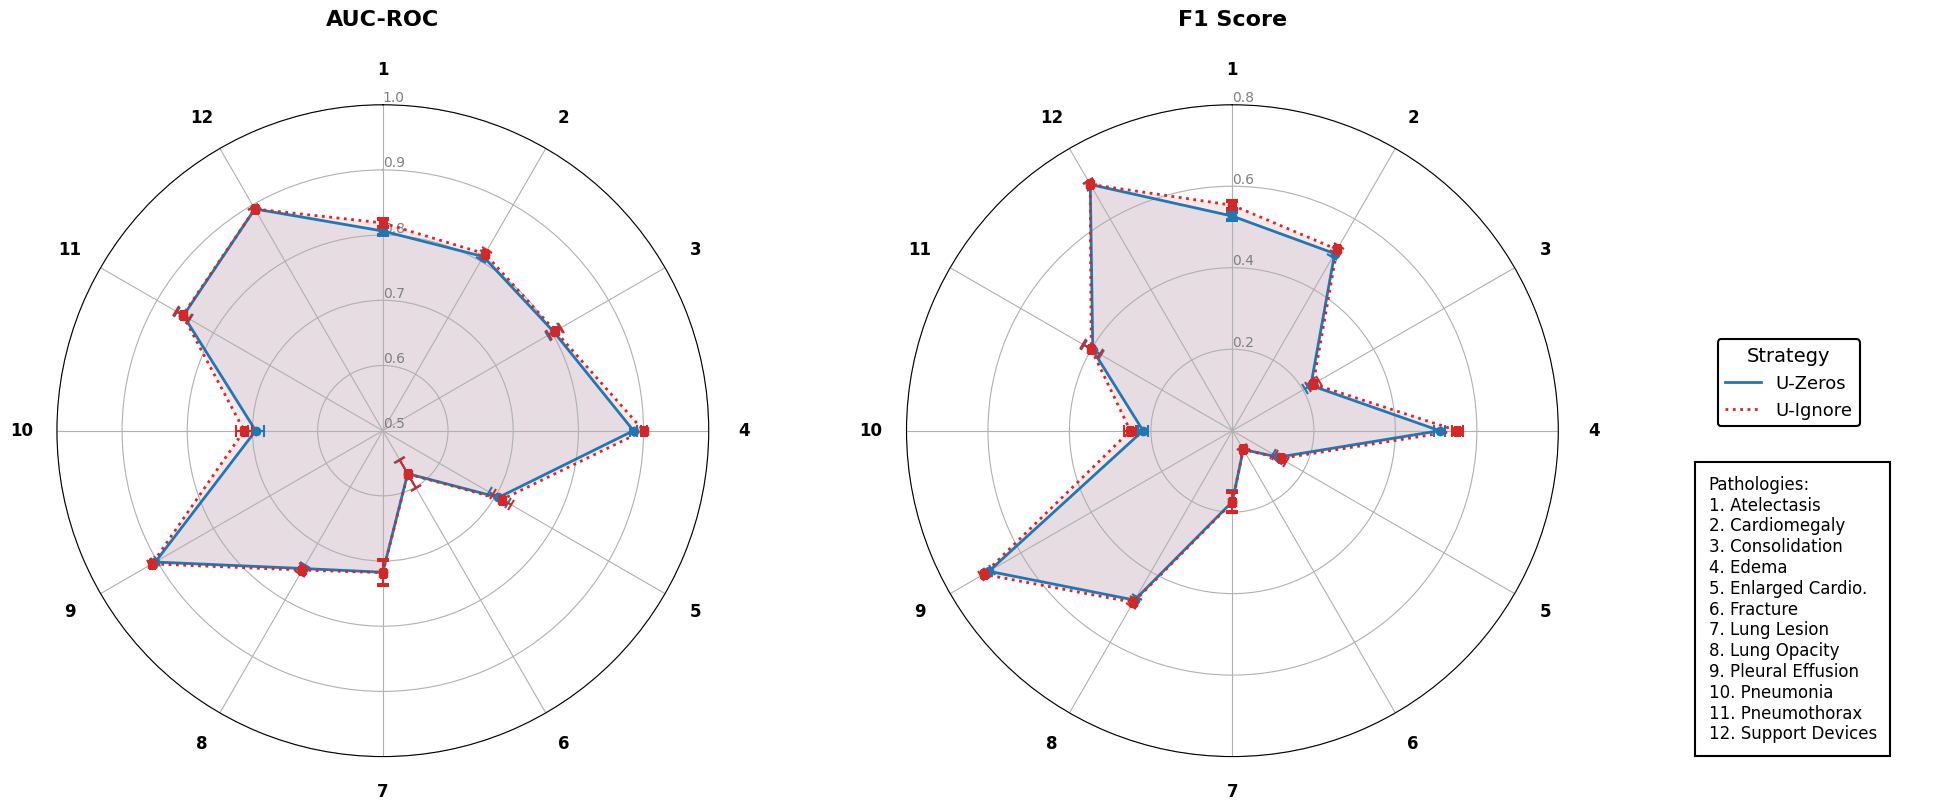

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ==========================================
# 1. PLUG IN YOUR DATA HERE (Swin-B)
# ==========================================
# The 12 categories for the radar chart axes
pathologies = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
    'Enlarged Cardio.', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
    'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices'
]
N = len(pathologies)
pathology_numbers = [str(i) for i in range(1, N + 1)]

# --- AUC-ROC DATA (Must be lists of 12 values) ---
# Format: [Value for Path 1, Path 2, ..., Path 12]
auc_uzeros_mean  = [0.8063, 0.8084, 0.8030, 0.8846, 0.7049, 0.5762, 0.7172, 0.7442, 0.9030, 0.6951, 0.8532, 0.8928]
auc_uzeros_lower = [0.8002, 0.8025, 0.7920, 0.8793, 0.6884, 0.5511, 0.6980, 0.7377, 0.8993, 0.6826, 0.8420, 0.8887]
auc_uzeros_upper = [0.8124, 0.8143, 0.8140, 0.8899, 0.7214, 0.6013, 0.7364, 0.7507, 0.9067, 0.7076, 0.8644, 0.8969]

auc_uignore_mean  = [0.8187, 0.8134, 0.8056, 0.9001, 0.7112, 0.5766, 0.7178, 0.7469, 0.9087, 0.7128, 0.8545, 0.8928]
auc_uignore_lower = [0.8130, 0.8075, 0.7948, 0.8954, 0.6951, 0.5519, 0.6990, 0.7404, 0.9050, 0.7006, 0.8433, 0.8885]
auc_uignore_upper = [0.8244, 0.8193, 0.8164, 0.9048, 0.7273, 0.6013, 0.7366, 0.7534, 0.9124, 0.7250, 0.8657, 0.8971]

# --- F1 SCORE DATA (Must be lists of 12 values) ---
f1_uzeros_mean  = [0.5267, 0.5020, 0.2223, 0.5085, 0.1300, 0.0533, 0.1742, 0.4802, 0.6903, 0.2194, 0.3957, 0.6978]
f1_uzeros_lower = [0.5171, 0.4910, 0.2070, 0.4952, 0.1147, 0.0460, 0.1491, 0.4708, 0.6817, 0.2067, 0.3720, 0.6888]
f1_uzeros_upper = [0.5363, 0.5130, 0.2376, 0.5218, 0.1453, 0.0606, 0.1993, 0.4896, 0.6989, 0.2321, 0.4194, 0.7068]

f1_uignore_mean  = [0.5534, 0.5138, 0.2289, 0.5523, 0.1365, 0.0533, 0.1758, 0.4866, 0.7051, 0.2506, 0.4003, 0.6982]
f1_uignore_lower = [0.5432, 0.5028, 0.2136, 0.5388, 0.1212, 0.0460, 0.1511, 0.4774, 0.6967, 0.2361, 0.3758, 0.6896]
f1_uignore_upper = [0.5636, 0.5248, 0.2442, 0.5658, 0.1518, 0.0606, 0.2005, 0.4958, 0.7135, 0.2651, 0.4248, 0.7068]

# ==========================================
# 2. HELPER FUNCTION TO CALCULATE ERROR
# ==========================================
def get_err(mean, lower, upper):
    mean, lower, upper = np.array(mean), np.array(lower), np.array(upper)
    return [mean - lower, upper - mean]

# ==========================================
# 3. RADAR CHART SETUP
# ==========================================
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the loop

def plot_radar(ax, metric_name, uzeros_m, uzeros_l, uzeros_u, uignore_m, uignore_l, uignore_u, y_lim, y_ticks):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # --- U-ZEROS PLOT ---
    uz_mean_closed = uzeros_m + uzeros_m[:1]
    ax.plot(angles, uz_mean_closed, linewidth=2, linestyle='solid', label='U-Zeros', color='#1f77b4')
    ax.fill(angles, uz_mean_closed, '#1f77b4', alpha=0.1)
    ax.errorbar(angles[:-1], uzeros_m, yerr=get_err(uzeros_m, uzeros_l, uzeros_u), 
                fmt='o', color='#1f77b4', capsize=4, capthick=1.5, elinewidth=1.5)

    # --- U-IGNORE PLOT ---
    ui_mean_closed = uignore_m + uignore_m[:1]
    ax.plot(angles, ui_mean_closed, linewidth=2, linestyle='dotted', label='U-Ignore', color='#d62728')
    ax.fill(angles, ui_mean_closed, '#d62728', alpha=0.1)
    ax.errorbar(angles[:-1], uignore_m, yerr=get_err(uignore_m, uignore_l, uignore_u), 
                fmt='s', color='#d62728', capsize=4, capthick=1.5, elinewidth=1.5)

    # --- FORMATTING ---
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(pathology_numbers, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', pad=15)
    
    ax.set_rlabel_position(0)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(t) for t in y_ticks], color="grey", size=10)
    ax.set_ylim(y_lim) 
    
    ax.set_title(metric_name, size=16, weight='bold', pad=25)

# ==========================================
# 4. DRAW FIGURE & LAYOUT (1x3 Grid with Custom Widths)
# ==========================================
# We shrink the overall width to 20, and use width_ratios to make the 3rd column much thinner!
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8), 
                                    subplot_kw=dict(polar=True),
                                    gridspec_kw={'width_ratios': [1, 1, 0.3]})

plot_radar(ax1, 'AUC-ROC', 
           auc_uzeros_mean, auc_uzeros_lower, auc_uzeros_upper,
           auc_uignore_mean, auc_uignore_lower, auc_uignore_upper,
           y_lim=(0.5, 1.0), y_ticks=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plot_radar(ax2, 'F1 Score', 
           f1_uzeros_mean, f1_uzeros_lower, f1_uzeros_upper,
           f1_uignore_mean, f1_uignore_lower, f1_uignore_upper,
           y_lim=(0.0, 0.8), y_ticks=[0.2, 0.4, 0.6, 0.8])

# --- CONFIGURE SUBPLOT 3 (THE LEGEND CANVAS) ---
ax3.axis('off')  

custom_lines = [Line2D([0], [0], color='#1f77b4', lw=2, linestyle='solid'),
                Line2D([0], [0], color='#d62728', lw=2, linestyle='dotted')]

# Pushed the anchor to 0.0 (the absolute left edge of this new, thinner 3rd column)
leg = ax3.legend(custom_lines, ['U-Zeros', 'U-Ignore'], loc='upper left', 
                 bbox_to_anchor=(0.0, 0.95), fontsize=13, title="Strategy", 
                 title_fontsize=14, frameon=True, edgecolor='black', facecolor='white', framealpha=1)
leg.get_frame().set_linewidth(1.5)

mapping_text = "Pathologies:\n" + "\n".join([f"{i}. {p}" for i, p in enumerate(pathologies, 1)])

# Pushed the text to 0.0 as well
ax3.text(0, 0.30, mapping_text, transform=ax3.transAxes, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle="square,pad=0.8", facecolor="white", edgecolor="black", linewidth=1.5))

plt.tight_layout()
plt.savefig('relabelling_radar.png', dpi=300, bbox_inches='tight')
print("Successfully saved to 'relabelling_radar.png'")